# BIM2GRAPH
Extrae de un modelo BIM en foramto IFC (2.3 o 4) un grafo (que se guarda en greopackage) con los nodos de los espacios, puertas escaleras y ascensores.
+


In [ ]:
!pip install ifcopenshell

## Definicion Clase _IMAccessibilityMapper_

In [ ]:
import ifcopenshell
import ifcopenshell.util.placement as placement
import ifcopenshell.util.element as ifc_element # Importar utilidad para buscar contenedores
import ifcopenshell.geom
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString
import os

class BIMAccessibilityMapper:
    def __init__(self, ifc_path):
        self.model = ifcopenshell.open(ifc_path)
        self.G = nx.Graph()
        self.filename = os.path.splitext(os.path.basename(ifc_path))[0]
        # Configuración global de geometría
        self.settings = ifcopenshell.geom.settings()
        self.settings.set(self.settings.USE_WORLD_COORDS, True)

        # --- Niveles (IfcBuildingStorey) y cotas de suelo ---
        # Usaremos la cota del suelo (Elevation) para "aplanar" la Z de los nodos por nivel.
        self.storey_by_name = {}
        self.storey_elev_by_name = {}

        # Recolectar niveles y sus elevaciones
        storeys = self.model.by_type("IfcBuildingStorey")
        for st in storeys:
            name = (st.Name or "Nivel Desconocido").strip()
            self.storey_by_name[name] = st
            elev = getattr(st, "Elevation", None)
            try:
                elev_val = float(elev) if elev is not None else 0.0
            except:
                elev_val = 0.0
            self.storey_elev_by_name[name] = elev_val

        # Si no se encontraron niveles, crear un nivel base 0.0 por defecto
        if not self.storey_elev_by_name:
             print("Advertencia: No se encontraron IfcBuildingStorey. Se asume Nivel 0 en Z=0.0")
             self.storey_elev_by_name["Nivel 0"] = 0.0

        # Lista de niveles ordenada por elevación
        self._sorted_storeys = sorted(self.storey_elev_by_name.items(), key=lambda kv: kv[1])
        print(f"Niveles detectados (por elevación): {self._sorted_storeys}")

    def get_element_geometry(self, element):
        """Calcula centroide y bounding box de un elemento usando su geometría real."""
        try:
            shape = ifcopenshell.geom.create_shape(self.settings, element)
            verts = shape.geometry.verts
            xs = verts[0::3]
            ys = verts[1::3]
            zs = verts[2::3]

            if not xs: return None, None

            # Centroide (promedio de vértices)
            centroid = (sum(xs)/len(xs), sum(ys)/len(ys), sum(zs)/len(zs))

            # Bounding Box (caja envolvente: min_x, min_y...)
            bbox = (min(xs), min(ys), min(zs), max(xs), max(ys), max(zs))

            return centroid, bbox
        except:
            # Fallback básico si falla la generación de geometría
            return None, None

    def snap_z_to_level(self, z_value: float) -> tuple[str, float]:
        """Asigna un Z a su nivel más cercano (por elevación) y devuelve (nivel, z_suelo)."""
        try:
            z = float(z_value)
        except:
            z = 0.0

        # Encontrar el nivel con la elevación más cercana
        closest_name, closest_elev = min(self._sorted_storeys, key=lambda kv: abs(kv[1] - z))
        return (closest_name, float(closest_elev))

    def check_proximity(self, point, bbox, tolerance=0.5):

        """Verifica si un punto está dentro o muy cerca de un Bounding Box."""
        px, py, pz = point
        min_x, min_y, min_z, max_x, max_y, max_z = bbox

        # Comprobamos si el punto está dentro de los límites expandidos por la tolerancia
        return ((min_x - tolerance <= px <= max_x + tolerance) and
                (min_y - tolerance <= py <= max_y + tolerance) and
                (min_z - tolerance <= pz <= max_z + tolerance))

    def extraer_datos(self):
        print("--- Extracción: PROXIMIDAD + VERTICALIDAD ASCENSORES + CONEXIÓN A PUERTAS ---")

        # 1. Procesar Espacios
        spaces_data = []

        print("Procesando Espacios...")
        for space in self.model.by_type("IfcSpace"):
            centroid, bbox = self.get_element_geometry(space)
            if centroid:
                # Usamos bbox[2] (min_z) para determinar el suelo de la habitación
                level_name, floor_z = self.snap_z_to_level(bbox[2])

                self.G.add_node(space.GlobalId,
                           name=space.Name or "Estancia",
                           type="Habitacion",
                           level=level_name,
                           x=float(centroid[0]), y=float(centroid[1]), z=float(floor_z),
                           accessible=True)
                spaces_data.append({'id': space.GlobalId, 'bbox': bbox, 'name': space.Name, 'level': level_name})

        # 1.5 Procesar Suelos (IfcSlab) para zonas sin IfcSpace
        print("Buscando Suelos (IfcSlab) en áreas vacías (Filtrando losas estructurales)...")
        for slab in self.model.by_type("IfcSlab"):
             # Excluir techos y losas base
             p_type = getattr(slab, "PredefinedType", "")
             if str(p_type).upper() in ["ROOF", "BASESLAB"]: continue

             centroid, bbox = self.get_element_geometry(slab)
             if not centroid: continue

             # FILTRO DE TAMAÑO: Si es muy grande (>10m x 10m), asumimos que es estructural y no un pasillo
             dx = bbox[3] - bbox[0]
             dy = bbox[4] - bbox[1]
             if dx > 10.0 and dy > 10.0:
                 continue

             # Verificar si este suelo ya está "cubierto" por un Espacio (IfcSpace)
             is_covered = False
             for sp in spaces_data:
                 if self.check_proximity(centroid, sp['bbox'], tolerance=0.1):
                     is_covered = True
                     break

             if not is_covered:
                 level_name, floor_z = self.snap_z_to_level(bbox[2])
                 self.G.add_node(slab.GlobalId,
                            name=slab.Name or "Suelo/Pasillo",
                            type="Suelo",
                            level=level_name,
                            x=float(centroid[0]), y=float(centroid[1]), z=float(floor_z),
                            accessible=True)
                 spaces_data.append({'id': slab.GlobalId, 'bbox': bbox, 'name': "Suelo", 'level': level_name})

        # 3. Procesar Puertas (IfcDoor)
        print("Procesando Puertas...")
        num_doors_found = 0
        doors_data = []

        for door in self.model.by_type("IfcDoor"):
            centroid, bbox = self.get_element_geometry(door)
            if not centroid: continue

            num_doors_found += 1
            level_name, floor_z = self.snap_z_to_level(bbox[2])
            width = getattr(door, "OverallWidth", 0.0)
            is_accessible = width >= 0.85
            weight = 1.0 if is_accessible else 999999

            self.G.add_node(door.GlobalId, type="Puerta", level=level_name,
                       x=float(centroid[0]), y=float(centroid[1]), z=float(floor_z),
                       width=width, accessible=is_accessible)

            doors_data.append({'id': door.GlobalId, 'x': centroid[0], 'y': centroid[1], 'level': level_name})

            # Conectar Puerta con Espacio
            for space_info in spaces_data:
                if space_info['level'] == level_name and self.check_proximity(centroid, space_info['bbox'], tolerance=0.5):
                    self.G.add_edge(door.GlobalId, space_info['id'], weight=weight, accessible=is_accessible)

        # 2. Procesar Escaleras (IfcStair, IfcStairFlight DESPUES DE PUERTAS/ESPACIOS)
        print("Procesando Escaleras...")
        num_stairs_found = 0
        stair_elements = self.model.by_type("IfcStair") + self.model.by_type("IfcStairFlight")
        processed_ids = set()

        for stair in stair_elements:
            if stair.GlobalId in processed_ids: continue
            try:
                shape = ifcopenshell.geom.create_shape(self.settings, stair)
                verts = shape.geometry.verts
                xs = verts[0::3]
                ys = verts[1::3]
                zs = verts[2::3]
                if not xs: continue

                min_z, max_z = min(zs), max(zs)
                idx_min, idx_max = zs.index(min_z), zs.index(max_z)
                p_start = (xs[idx_min], ys[idx_min], zs[idx_min])
                p_end = (xs[idx_max], ys[idx_max], zs[idx_max])

                level_start, floor_z_start = self.snap_z_to_level(p_start[2])
                level_end, floor_z_end = self.snap_z_to_level(p_end[2])

                id_start, id_end = f"{stair.GlobalId}_START", f"{stair.GlobalId}_END"

                self.G.add_node(id_start, name="Escalera Inicio", type="Escalera", level=level_start,
                           x=float(p_start[0]), y=float(p_start[1]), z=float(floor_z_start), accessible=False)
                self.G.add_node(id_end, name="Escalera Fin", type="Escalera", level=level_end,
                           x=float(p_end[0]), y=float(p_end[1]), z=float(floor_z_end), accessible=False)
                self.G.add_edge(id_start, id_end, weight=999999, accessible=False)

                # --- Conectar escaleras (CONTAINMENT CHECK) ---
                for space_info in spaces_data:
                    if space_info['level'] == level_start and self.check_proximity(p_start, space_info['bbox'], tolerance=0.2):
                        self.G.add_edge(id_start, space_info['id'], weight=1.0, accessible=True)

                for space_info in spaces_data:
                    if space_info['level'] == level_end and self.check_proximity(p_end, space_info['bbox'], tolerance=0.2):
                        self.G.add_edge(id_end, space_info['id'], weight=1.0, accessible=True)

                num_stairs_found += 1
                processed_ids.add(stair.GlobalId)
            except:
                continue

        # 4. Procesar Ascensores (IfcTransportElement)
        print("Procesando Ascensores...")
        num_lifts_found = 0
        for lift in self.model.by_type("IfcTransportElement"):
            name_tag = (lift.Name or "").upper()
            obj_tag = (lift.ObjectType or "").upper()

            if "ASCENSOR" in name_tag or "ELEVATOR" in name_tag or "ASCENSOR" in obj_tag or "ELEVATOR" in obj_tag:
                centroid, bbox = self.get_element_geometry(lift)
                if not centroid: continue

                num_lifts_found += 1
                prev_node_id = None

                for (lvl_name, lvl_z) in self._sorted_storeys:
                    node_id = f"{lift.GlobalId}_{lvl_name}"
                    self.G.add_node(node_id, name="Ascensor", type="Ascensor", level=lvl_name,
                               x=float(centroid[0]), y=float(centroid[1]), z=float(lvl_z), accessible=True)

                    if prev_node_id:
                        self.G.add_edge(prev_node_id, node_id, weight=1.0, accessible=True)
                    prev_node_id = node_id

                    connected_to_door = False
                    for door_info in doors_data:
                        if door_info['level'] == lvl_name:
                            dist = ((door_info['x'] - centroid[0])**2 + (door_info['y'] - centroid[1])**2)**0.5
                            if dist < 2.0:
                                self.G.add_edge(node_id, door_info['id'], weight=1.0, accessible=True)
                                connected_to_door = True

                    if not connected_to_door:
                        p_level = (centroid[0], centroid[1], lvl_z)
                        for space_info in spaces_data:
                             if space_info['level'] == lvl_name and self.check_proximity(p_level, space_info['bbox'], tolerance=0.5):
                                  self.G.add_edge(node_id, space_info['id'], weight=1.0, accessible=True)

        print(f"Total espacios: {len(spaces_data)} | Puertas: {num_doors_found} | Escaleras: {num_stairs_found} | Ascensores: {num_lifts_found}")
        print(f"Grafo final: {self.G.number_of_nodes()} nodos, {self.G.number_of_edges()} aristas.")

    def calcular_ruta(self, start_node_id, end_node_id):
        # ... (sin cambios)
        try:
            accessible_subgraph = self.G.edge_subgraph([(u, v) for u, v, d in self.G.edges(data=True) if d.get('accessible', True)])
            path = nx.shortest_path(accessible_subgraph, source=start_node_id, target=end_node_id, weight='weight')
            return path
        except: return "No existe ruta."

    def exportar_geopackage(self):
        """Exporta a GPKG incluyendo el nivel."""
        nodes_data = []
        for n, attr in self.G.nodes(data=True):
            nodes_data.append({
                'geometry': Point(attr['x'], attr['y'], attr['z']),
                'id': n, 'tipo': attr['type'],
                'level': attr.get('level', 'Desconocido'),
                'acc': attr.get('accessible', True)
            })

        if nodes_data:
            gdf_nodes = gpd.GeoDataFrame(nodes_data, crs="EPSG:4326")
            gdf_nodes.to_file(f"{self.filename}_grafo.gpkg", layer='nodos', driver="GPKG")

        edges_data = []
        for u, v, attr in self.G.edges(data=True):
            p1, p2 = self.G.nodes[u], self.G.nodes[v]
            # Asignamos a la arista los niveles de sus extremos para poder filtrar correctamente
            lvl_u = p1.get('level', 'Desconocido')
            lvl_v = p2.get('level', 'Desconocido')
            levels = "|".join(sorted(set([str(lvl_u), str(lvl_v)])))
            line = LineString([(p1['x'], p1['y'], p1['z']), (p2['x'], p2['y'], p2['z'])])
            edges_data.append({'geometry': line, 'acc': attr.get('accessible', True), 'levels': levels})

        if edges_data:
            gdf_edges = gpd.GeoDataFrame(edges_data, crs="EPSG:4326")
            gdf_edges.to_file(f"{self.filename}_grafo.gpkg", layer='caminos', driver="GPKG")

        print(f"Archivos exportados con datos de nivel: {self.filename}_grafo.gpkg")

# Ejecución de IFC2GRAPH  
--- INSTRUCCIONES DE USO ---
1. Sube tu archivo .ifc a la carpeta de la izquierda en Colab.
2. mapper = BIMAccessibilityMapper("mi_edificio.ifc")
3. mapper.extraer_datos()
4. mapper.exportar_geopackage()



###### Explicación Técnica
**Identificación de Barreras**: El código marca automáticamente las escaleras como nodos no accesibles y penaliza las puertas con ancho insuficiente (`< 0.85m`) asignándoles un peso infinito en el algoritmo de búsqueda.


* **Visualización en QGIS**: El archivo **GeoPackage (.gpkg)** generado contiene coordenadas **Z** reales. Para visualizarlo en 3D:
1. Carga el archivo en QGIS.
2. Usa el plugin **QGIS2threejs**.
3. En la configuración de la capa de "caminos", selecciona que la elevación provenga de las coordenadas de la geometría (Z).


* **Algoritmo de Navegación**: He implementado una versión de **Dijkstra** que opera sobre un subgrafo filtrado. Esto garantiza que el sistema nunca proponga una ruta que pase por una escalera o una puerta estrecha.



In [ ]:
from google.colab import files
import os

# 1. Configura el nombre de tu archivo subido
#archivo_ifc = "/content/EPM_trocin.ifc"
archivo_ifc = "/content/ProyectoParaGrafoAccesibilidad_bis.ifc"
if os.path.exists(archivo_ifc):
    # 2. Instanciar la herramienta (Se recarga para aplicar la lógica de Niveles)
    print("--- RE-EJECUTANDO EXTRACCIÓN SIN LOSAS ESTRUCTURALES ---")
    mapper = BIMAccessibilityMapper(archivo_ifc)

    print(f"--- Iniciando extracción de datos (GEOMETRÍA + FILTER BIG SLABS) de: {archivo_ifc} ---")
    mapper.extraer_datos()

    # 3. Exportar el GeoPackage para QGIS
    mapper.exportar_geopackage()

    # 4. Listar nodos para probar una ruta y VERIFICAR COORDENADAS
    print("\nNodos extraídos (primeros 5) con coordenadas:")
    nodos = list(mapper.G.nodes(data=True))[:5]
    for id_nodo, datos in nodos:
        print(f"ID: {id_nodo} | Tipo: {datos['type']} | Nivel: {datos.get('level', 'N/A')} | Pos: ({datos['x']:.2f}, {datos['y']:.2f}, {datos['z']:.2f})")

    # 5. Descargar automáticamente el resultado
    resultado_gpkg = f"{mapper.filename}_grafo.gpkg"
    if os.path.exists(resultado_gpkg):
        try:
            files.download(resultado_gpkg)
        except:
            pass
else:
    print(f"Error: No se encuentra el archivo '{archivo_ifc}'. Asegúrate de haberlo subido al panel lateral.")

--- RE-EJECUTANDO EXTRACCIÓN SIN LOSAS ESTRUCTURALES ---
Niveles detectados (por elevación): [('Nivel 1', 0.0), ('Nivel 2', 2.9999999999999996), ('Nivel 3', 5.999999999999998)]
--- Iniciando extracción de datos (GEOMETRÍA + FILTER BIG SLABS) de: /content/ProyectoParaGrafoAccesibilidad_bis.ifc ---
--- Extracción: PROXIMIDAD + VERTICALIDAD ASCENSORES + CONEXIÓN A PUERTAS ---
Procesando Espacios...
Buscando Suelos (IfcSlab) en áreas vacías (Filtrando losas estructurales)...
Procesando Puertas...
Procesando Escaleras...
Procesando Ascensores...
Total espacios: 11 | Puertas: 10 | Escaleras: 1 | Ascensores: 1
Grafo final: 26 nodos, 26 aristas.
Archivos exportados con datos de nivel: ProyectoParaGrafoAccesibilidad_bis_grafo.gpkg

Nodos extraídos (primeros 5) con coordenadas:
ID: 24DYKCxdv3Ewxlr3jXUnBN | Tipo: Habitacion | Nivel: Nivel 1 | Pos: (16.35, 3.29, 0.00)
ID: 24DYKCxdv3Ewxlr3jXUnBI | Tipo: Habitacion | Nivel: Nivel 1 | Pos: (12.01, 6.85, 0.00)
ID: 24DYKCxdv3Ewxlr3jXUnBH | Tipo: Habita

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###### Diagnostico escaleras

# Gráfico de nodos y conexiones

In [ ]:
import plotly.graph_objects as go
import geopandas as gpd
import pandas as pd
import os

gpkg_filename = resultado_gpkg

if os.path.exists(gpkg_filename):
    print("Generando visualización interactiva FINAL (Limpieza de Losas)...")

    # Cargar datos
    gdf_nodos = gpd.read_file(gpkg_filename, layer='nodos')
    try:
        gdf_caminos = gpd.read_file(gpkg_filename, layer='caminos')
    except:
        gdf_caminos = gpd.GeoDataFrame(columns=['geometry', 'level'])

    data_traces = []

    # Garantizar campo 'level'
    if 'level' not in gdf_nodos.columns: gdf_nodos['level'] = 'Desconocido'
    if 'level' not in gdf_caminos.columns: gdf_caminos['level'] = 'Desconocido'
    # Compatibilidad: nuevo campo 'levels' (niveles de ambos extremos)
    if 'levels' not in gdf_caminos.columns:
        gdf_caminos['levels'] = gdf_caminos['level'].astype(str)

    niveles = sorted(gdf_nodos['level'].unique().tolist())

    # Estilos
    styles = {
        'Habitacion': {'color': '#1f77b4', 'symbol': 'circle',  'size': 6},
        'Puerta':     {'color': '#2ca02c', 'symbol': 'diamond', 'size': 5},
        'Escalera':   {'color': '#d62728', 'symbol': 'square',  'size': 5},
        'Ascensor':   {'color': '#9467bd', 'symbol': 'x',       'size': 5},
        'Suelo':      {'color': '#e377c2', 'symbol': 'circle-open', 'size': 4} # Nuevo Estilo
    }

    # --- GENERACIÓN DE TRAZAS ---
    trace_indices_by_level = {lvl: [] for lvl in niveles}
    current_idx = 0

    for nivel in niveles:
        # 1. ARISTAS (Color naranja)
        edges_subset = gdf_caminos[gdf_caminos['levels'].astype(str).str.contains(str(nivel), na=False)]
        edge_x, edge_y, edge_z = [], [], []
        for line in edges_subset.geometry:
            coords = list(line.coords)
            for i in range(len(coords)-1):
                p1, p2 = coords[i], coords[i+1]
                edge_x.extend([p1[0], p2[0], None])
                edge_y.extend([p1[1], p2[1], None])
                edge_z.extend([p1[2], p2[2], None])

        trace_edges = go.Scatter3d(
            x=edge_x, y=edge_y, z=edge_z, mode='lines',
            line=dict(color='#FF5733', width=4), # Naranja
            hoverinfo='none', name=f'Conexiones ({nivel})',
            visible=True
        )
        data_traces.append(trace_edges)
        trace_indices_by_level[nivel].append(current_idx)
        current_idx += 1

        # 2. NODOS
        nodos_subset = gdf_nodos[gdf_nodos['level'] == nivel]
        for node_type in nodos_subset['tipo'].unique():
            subset = nodos_subset[nodos_subset['tipo'] == node_type]
            style = styles.get(node_type, {'color': 'gray', 'symbol': 'circle', 'size': 5})

            trace_node = go.Scatter3d(
                x=subset.geometry.x, y=subset.geometry.y, z=subset.geometry.z,
                mode='markers',
                marker=dict(size=style['size'], color=style['color'], symbol=style['symbol'], opacity=0.9),
                text=subset['tipo'] + "<br>ID: " + subset['id'].astype(str) + "<br>Nivel: " + subset['level'],
                name=f"{node_type} ({nivel})",
                visible=True
            )
            data_traces.append(trace_node)
            trace_indices_by_level[nivel].append(current_idx)
            current_idx += 1

    # --- CONFIGURACIÓN DEL MENÚ ---
    buttons = []
    buttons.append(dict(
        label="Mostrar Todos",
        method="update",
        args=[{"visible": [True] * len(data_traces)},
              {"title": "Grafo Completo"}]
    ))

    for nivel in niveles:
        visibility = [False] * len(data_traces)
        for idx in trace_indices_by_level[nivel]:
            visibility[idx] = True
        buttons.append(dict(
            label=f"Ver {nivel}",
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Vista: {nivel}"}]
        ))

    # --- LAYOUT ---
    layout = go.Layout(
        template=None,
        title=dict(
            text="Grafo de Accesibilidad Interactiva",
            font=dict(color='black', size=16),
            y=0.95, x=0.5, xanchor='center', yanchor='top'
        ),
        # Configuración Global de Fuente
        font=dict(family="Arial", size=12, color="black"),

        updatemenus=[dict(
            type="dropdown",
            active=0,
            buttons=buttons,
            direction="down",
            x=0.0, y=1.15,
            xanchor="left", yanchor="top",
            # Fondo gris claro para asegurar contraste si la fuente se fuerza a blanco
            bgcolor='#333333',
            font=dict(color='white'),
            bordercolor='gray', borderwidth=1,
            pad=dict(r=10, t=10)
        )],
        scene=dict(
            xaxis=dict(title='X', color='black', showbackground=False, titlefont=dict(color='white'), tickfont=dict(color='black')),
            yaxis=dict(title='Y', color='black', showbackground=False, titlefont=dict(color='white'), tickfont=dict(color='black')),
            zaxis=dict(title='Z', color='black', showbackground=False, titlefont=dict(color='white'), tickfont=dict(color='black')),
            aspectmode='data',
            camera=dict(projection=dict(type="orthographic"))
        ),
        paper_bgcolor='white',
        plot_bgcolor='white',
        legend=dict(
            yanchor="top", y=0.9, xanchor="left", x=0.01,
            font=dict(color='white'),
            # Fondo gris claro también para la leyenda
            bgcolor='#333333',
            bordercolor='gray', borderwidth=1
        ),
        margin=dict(t=80, b=0, l=0, r=0)
    )

    fig = go.Figure(data=data_traces, layout=layout)
    fig.show()
else:
    print("Error: Archivo GPKG no encontrado.")

Generando visualización interactiva FINAL (Limpieza de Losas)...


In [ ]:
# --- DIAGNÓSTICO DE CONEXIONES DEL ASCENSOR ---
print("--- CONEXIONES DEL ASCENSOR ---")

# Buscar todos los nodos de ascensor
lift_nodes = [n for n, d in mapper.G.nodes(data=True) if d.get('type') == 'Ascensor']

if not lift_nodes:
    print("No hay nodos de ascensor en el grafo.")
else:
    for lift_node in lift_nodes:
        data = mapper.G.nodes[lift_node]
        neighbors = list(mapper.G.neighbors(lift_node))
        print(f"\nAscensor en {data['level']} (ID: {lift_node}):")
        print(f"  Posición: ({data['x']:.2f}, {data['y']:.2f}, {data['z']:.2f})")
        print(f"  Conectado a {len(neighbors)} nodos:")
        for nb in neighbors:
            nb_data = mapper.G.nodes[nb]
            print(f"    -> {nb_data['type']} en {nb_data.get('level', '?')} (ID: {nb})")

    # Verificar distancia a la puerta más cercana en Nivel 1
    print("\n--- DISTANCIAS EN NIVEL 1 ---")
    lift_n1 = next((n for n in lift_nodes if 'Nivel 1' in n), None)
    if lift_n1:
        l_x, l_y = mapper.G.nodes[lift_n1]['x'], mapper.G.nodes[lift_n1]['y']
        doors_n1 = [n for n, d in mapper.G.nodes(data=True) if d.get('type') == 'Puerta' and d.get('level') == 'Nivel 1']

        print(f"Ascensor N1 en ({l_x:.2f}, {l_y:.2f}). Puertas cercanas:")
        for dn in doors_n1:
            d_data = mapper.G.nodes[dn]
            dist = ((d_data['x'] - l_x)**2 + (d_data['y'] - l_y)**2)**0.5
            print(f"  - Puerta {dn}: Distancia = {dist:.2f} m {'(CONECTADA)' if dist < 2.0 else '(muy lejos)'}")

--- CONEXIONES DEL ASCENSOR ---

Ascensor en Nivel 1 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 1):
  Posición: (13.53, 9.41, 0.00)
  Conectado a 2 nodos:
    -> Puerta en Nivel 1 (ID: 24DYKCxdv3Ewxlr3jXUmXN)
    -> Ascensor en Nivel 2 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 2)

Ascensor en Nivel 2 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 2):
  Posición: (13.53, 9.41, 3.00)
  Conectado a 3 nodos:
    -> Ascensor en Nivel 1 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 1)
    -> Puerta en Nivel 2 (ID: 24DYKCxdv3Ewxlr3jXUmWC)
    -> Ascensor en Nivel 3 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 3)

Ascensor en Nivel 3 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 3):
  Posición: (13.53, 9.41, 6.00)
  Conectado a 1 nodos:
    -> Ascensor en Nivel 2 (ID: 24DYKCxdv3Ewxlr3jXUmkn_Nivel 2)

--- DISTANCIAS EN NIVEL 1 ---
Ascensor N1 en (13.53, 9.41). Puertas cercanas:
  - Puerta 24DYKCxdv3Ewxlr3jXUnDt: Distancia = 8.63 m (muy lejos)
  - Puerta 24DYKCxdv3Ewxlr3jXUnCS: Distancia = 5.94 m (muy lejos)
  - Puerta 24DYKCxdv3Ewxlr3jXUnCb: Distancia = 3.09

In [ ]:
# Contar ascensores en el grafo
num_ascensores = len([n for n, d in mapper.G.nodes(data=True) if d.get('type') == 'Ascensor'])
print(f"Número de ascensores detectados en el grafo: {num_ascensores}")

Número de ascensores detectados en el grafo: 3


# Exportación Geopackage

--- Cargando y visualizando el archivo GeoPackage: ProyectoParaGrafoAccesibilidad_bis_grafo.gpkg ---
Nodos cargados (Geometría):
         tipo                      geometry
0  Habitacion  POINT Z (16.34567 3.29398 0)
1  Habitacion  POINT Z (12.01125 6.85327 0)
2  Habitacion   POINT Z (6.71401 5.37732 0)
3  Habitacion   POINT Z (3.50401 6.94398 0)
4  Habitacion  POINT Z (15.96567 8.07198 0)


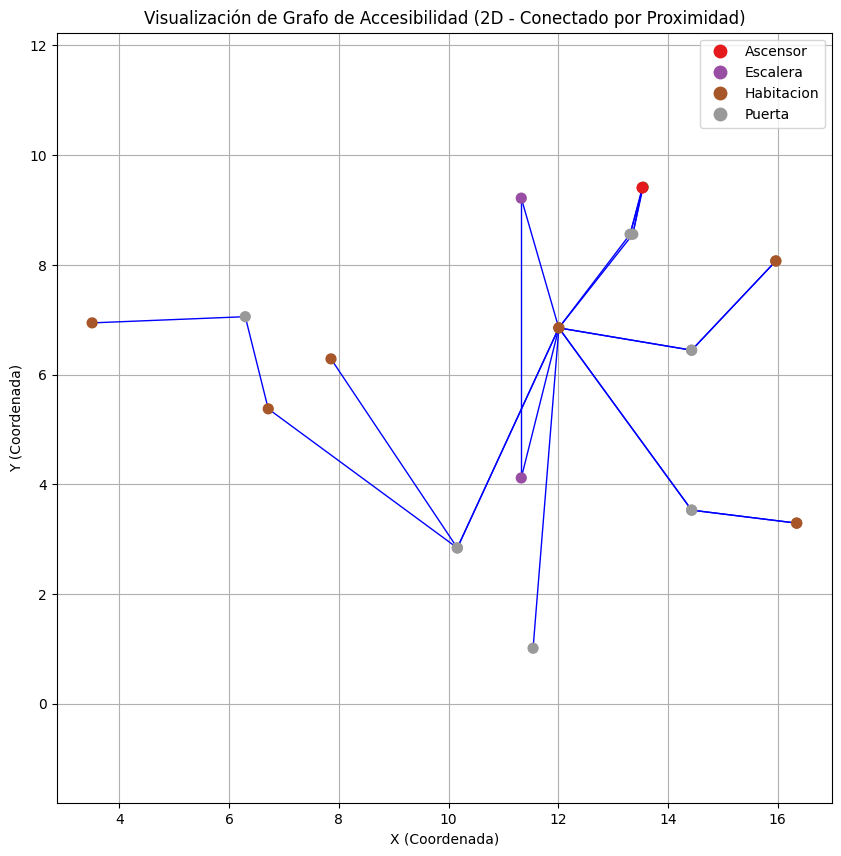

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import fiona

# Define el nombre del archivo GeoPackage que se generó
gpkg_filename =  resultado_gpkg

if os.path.exists(gpkg_filename):
    print(f"--- Cargando y visualizando el archivo GeoPackage: {gpkg_filename} ---")

    # Cargar la capa de nodos
    gdf_nodos = gpd.read_file(gpkg_filename, layer='nodos')
    print("Nodos cargados (Geometría):")
    print(gdf_nodos[['tipo', 'geometry']].head())

    # Cargar la capa de caminos
    if 'caminos' in fiona.listlayers(gpkg_filename):
         gdf_caminos = gpd.read_file(gpkg_filename, layer='caminos')
    else:
         gdf_caminos = gpd.GeoDataFrame()

    # Visualización básica
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Plot only if GeoDataFrames are not empty
    if not gdf_caminos.empty:
        gdf_caminos.plot(ax=ax, color='blue', linewidth=1, label='Caminos')
    else:
        print("No hay caminos para visualizar.")

    if not gdf_nodos.empty:
        gdf_nodos.plot(ax=ax, column='tipo', legend=True, markersize=50, zorder=2, cmap='Set1')
    else:
        print("No hay nodos para visualizar.")

    plt.title('Visualización de Grafo de Accesibilidad (2D - Conectado por Proximidad)')
    plt.xlabel('X (Coordenada)')
    plt.ylabel('Y (Coordenada)')
    plt.grid(True)
    plt.axis('equal')
    plt.show()
else:
    print(f"Error: No se encontró el archivo GeoPackage '{gpkg_filename}'.")